In [1]:
# Import libraries
import duckdb
import pandas as pd

In [2]:
conn = duckdb.connect("/Users/austinmartinez/Documents/MEDS/EDS-213/eds213-salmon_database/database/Biocomplexity_database.db")

In [18]:
result = conn.execute("""
    SELECT 
        prey_fish.preyspecies,
        COUNT(*) AS times_eaten
    FROM predator_fish
    JOIN diet ON predator_fish.scalelabel = diet.scalelabel
    JOIN prey_fish ON diet.gutlabel = prey_fish.gutlabel
    WHERE predator_fish.species = 'SMB'
    GROUP BY prey_fish.preyspecies
    ORDER BY times_eaten DESC
""").df()

print(result)

         preyspecies  times_eaten
0  unidentified fish          116
1       mimic shiner           83
2              smelt           24
3            sculpin            9
4   bluntnose minnow            7
5          smelt YOY            7
6        stickleback            1
7             minnow            1
8    smallmouth bass            1


In [32]:
result = conn.execute("""
    SELECT 
        prey_fish.preyspecies AS prey,
        COUNT(*) AS times_eaten
    FROM predator_fish
    JOIN diet ON predator_fish.scalelabel = diet.scalelabel
    JOIN prey_fish ON diet.gutlabel = prey_fish.gutlabel
    WHERE predator_fish.species = 'SMB'
    GROUP BY prey_fish.preyspecies

    UNION ALL

    SELECT 
        'crayfish' AS prey,
        COUNT(*) AS times_eaten
    FROM predator_fish
    JOIN diet ON predator_fish.scalelabel = diet.scalelabel
    JOIN prey_crayfish ON diet.gutlabel = prey_crayfish.gutlabel
    WHERE predator_fish.species = 'SMB'

    ORDER BY times_eaten DESC
""").df()

print(result)

                prey  times_eaten
0           crayfish          268
1  unidentified fish          116
2       mimic shiner           83
3              smelt           24
4            sculpin            9
5          smelt YOY            7
6   bluntnose minnow            7
7    smallmouth bass            1
8             minnow            1
9        stickleback            1


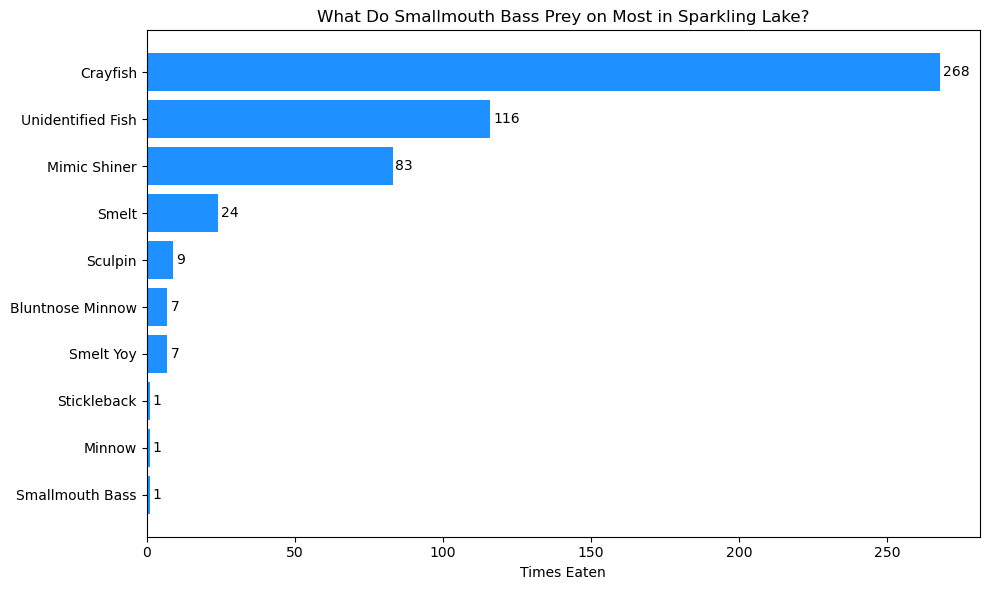

In [34]:
result_sorted = result.sort_values("times_eaten", ascending=True)
result_sorted['prey'] = result_sorted['prey'].str.title()

plt.figure(figsize=(10, 6))
plt.barh(result_sorted['prey'], result_sorted['times_eaten'], color='dodgerblue')

for idx, value in enumerate(result_sorted['times_eaten']):
    plt.text(
        value + 1,
        idx,
        str(value),
        va='center', fontsize=10
    )

plt.xlabel("Times Eaten")
plt.title("What Do Smallmouth Bass Prey on Most in Sparkling Lake?")
plt.tight_layout()
plt.show()